# Quality evaluation of the Born approximation as well as the Rytov approximation for the *plane-wave scattering Taylor vortex* problem

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from vortex2dscatter import Mach1Scatter2D

In [ ]:
def build_taylor_mach1(wavelength, mach, domain, mesh):
    return Mach1Scatter2D(wavelength).init_mesh(domain, mesh).add_taylor_vortex(mach).complete()


def directivity_after_direct_solve(model, radius, ntheta, bound, maxiter=50, tol=1e-11):
    model.complete().solve(maxiter=maxiter, tol=tol)
    return model.directivity(radius=radius, ntheta=ntheta, low=-bound, high=bound)[1]


def born_and_rytov_directivities(model, radius, ntheta, bound):
    model.complete().born_step()
    theta, born1 = model.directivity(radius=radius, ntheta=ntheta, low=-bound, high=bound)

    model.born_step()
    _, born2 = model.directivity(radius=radius, ntheta=ntheta, low=-bound, high=bound)

    model.complete().rytov_step()
    _, rytov = model.directivity(radius=radius, ntheta=ntheta, low=-bound, high=bound)
    return theta, born1, born2, rytov


cases = [
    dict(name="lambda16", wavelength=16.0, mach=0.1, domain=6.0, mesh=72, bound=np.pi, xlim=(-181, 181)),
    dict(name="lambda4", wavelength=4.0, mach=0.1, domain=6.0, mesh=72, bound=np.pi, xlim=(-181, 181)),
    dict(name="lambda1", wavelength=1.0, mach=0.1, domain=6.0, mesh=72, bound=np.pi/2, xlim=(-91, 91)),
    dict(name="lambda05", wavelength=0.5, mach=0.1, domain=5.5, mesh=176, bound=np.pi/4, xlim=(-41, 41), ylim=(-0.05, 3.0)),
]

radius = 8.0
ntheta = 361
results = []
for case in cases:
    model = build_taylor_mach1(case["wavelength"], case["mach"], case["domain"], case["mesh"])
    theta, born1, born2, rytov = born_and_rytov_directivities(model, radius, ntheta, case["bound"])
    direct = directivity_after_direct_solve(model, radius, ntheta, case["bound"])
    results.append(dict(case=case, theta=theta, direct=direct, born1=born1, born2=born2, rytov=rytov))


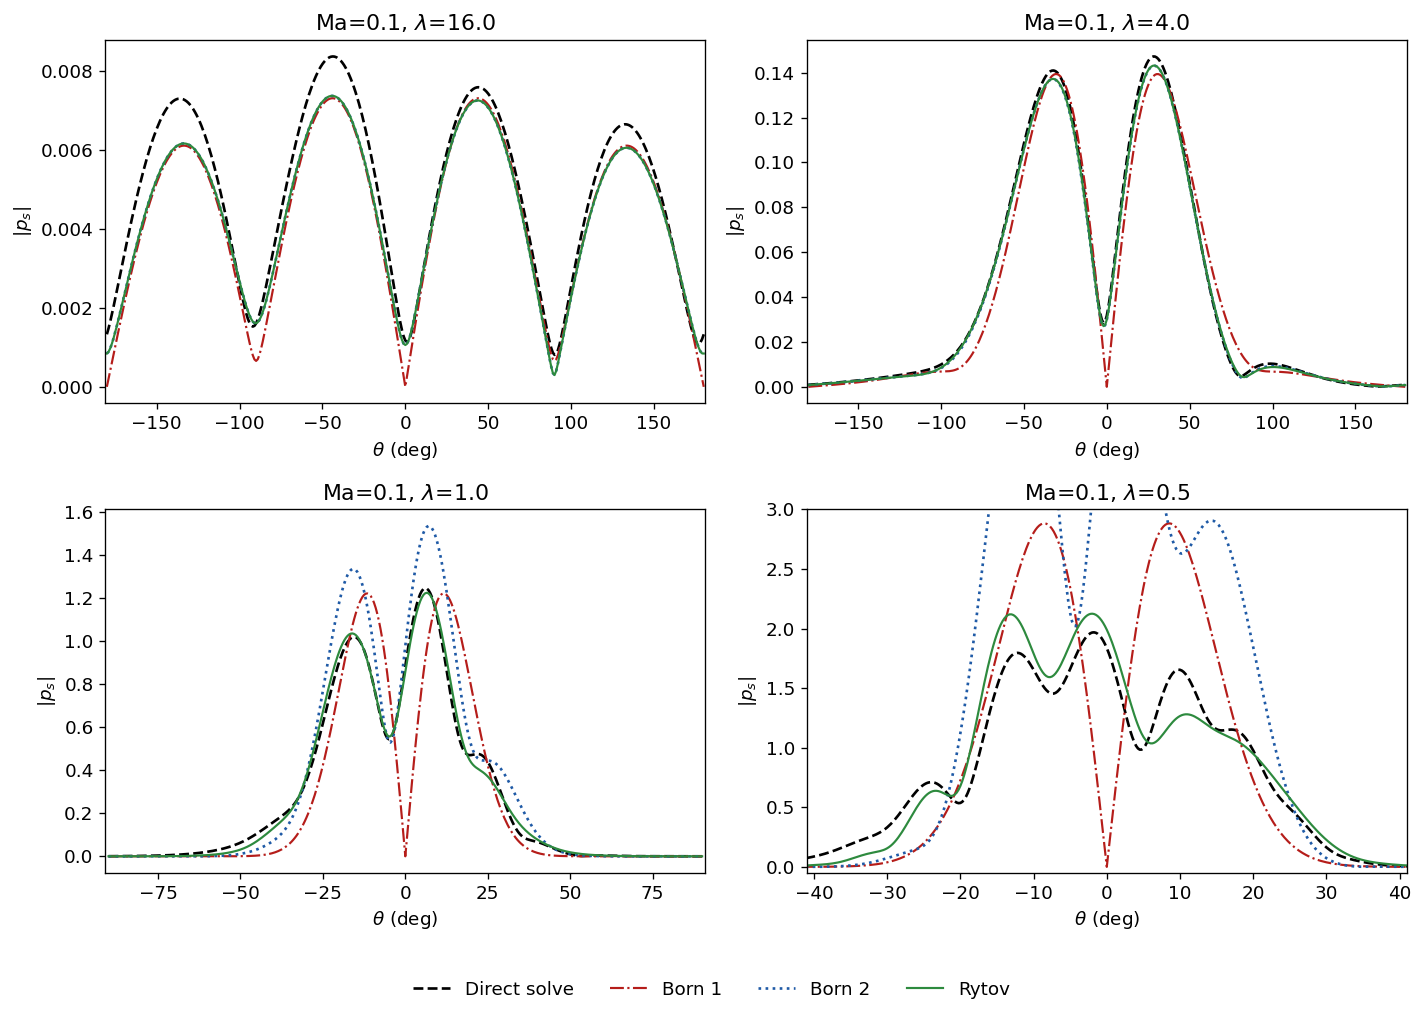

In [3]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8.5))
style = {
    "direct": dict(color="black", ls="--", lw=1.6, label="Direct solve"),
    "born1": dict(color="#b51d1a", ls="-.", lw=1.3, label="Born 1"),
    "born2": dict(color="#1f5aa6", ls=":", lw=1.6, label="Born 2"),
    "rytov": dict(color="#2d8a3e", ls="-", lw=1.3, label="Rytov"),
}

for ax, result in zip(axs.flat, results):
    case = result["case"]
    deg = result["theta"] * 180 / np.pi
    ax.plot(deg, np.abs(result["direct"]), **style["direct"])
    ax.plot(deg, np.abs(result["born1"]), **style["born1"])
    ax.plot(deg, np.abs(result["born2"]), **style["born2"])
    ax.plot(deg, np.abs(result["rytov"]), **style["rytov"])
    ax.set_xlim(case["xlim"])
    if "ylim" in case:
        ax.set_ylim(case["ylim"])
    ax.set_xlabel(r"$\theta$ (deg)")
    ax.set_ylabel(r"$|p_s|$")
    ax.set_title(rf"Ma={case['mach']}, $\lambda$={case['wavelength']}")

handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, frameon=False)
fig.tight_layout(rect=(0, 0.06, 1, 1))
